# Baseline fine-tune: CafeBERT on ViHSD

**Locked notebook** — backbone and hyperparameters are fixed. Just Run All.

LR = 2e-5 / 5e-5, identical to the proposed ViAmpleHate protocol. Effective batch = 32, same as the proposed notebook.

In [1]:
!pip install transformers datasets sentencepiece huggingface_hub -q

In [2]:
import os, re, time, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)
from transformers import AutoTokenizer, AutoModel, AutoConfig, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
# ============ LOCKED CONFIG — CafeBERT on ViHSD ============
# Learning rate is now IDENTICAL to the proposed ViAmpleHate-PhoBERT protocol
# (LR=2e-5, HEAD_LR=5e-5) so the comparison is strictly controlled:
# same data, same preprocessing, same effective batch, same LR — only the
# backbone changes.
#
# BATCH_SIZE / GRAD_ACCUM differ per model ONLY to fit VRAM; the effective
# batch (32) is identical to the proposed notebook, so this is equivalent.
BACKBONE = 'uitnlp/CafeBERT'
# ==============================================================

MODEL_NAME = BACKBONE
MAX_LEN    = 256

_cfg       = AutoConfig.from_pretrained(MODEL_NAME)
HIDDEN_DIM = _cfg.hidden_size

BATCH_SIZE      = 8
GRAD_ACCUM      = 4      # effective batch = 32
LR              = 2e-5    # <-- unified with the proposed protocol
HEAD_LR         = 5e-5    # <-- unified with the proposed protocol
GRADIENT_CKPT   = True

NUM_EPOCHS      = 8
WARMUP_RATIO    = 0.06
DROPOUT         = 0.1
PATIENCE        = 2
WEIGHT_DECAY    = 0.01
LABEL_SMOOTHING = 0.05

NUM_CLASSES = 2
LABEL_NAMES = ['NON-HATE', 'HATE']
MODEL_TAG   = 'cafebert'
RUN_TAG     = f'{MODEL_TAG}_vihsd_lr2e5'
CKPT_NAME   = f'best_baseline_{RUN_TAG}.pt'
PLOT_TITLE  = f'Baseline fine-tune (CafeBERT, LR=2e-5) — ViHSD'

# --- Fill in YOUR ViAmpleHate (proposed) TEST results to get delta columns ---
PROPOSED_MACRO_F1 = None
PROPOSED_HATE_F1  = None

print(f'Backbone: {MODEL_NAME} | hidden={HIDDEN_DIM} | batch={BATCH_SIZE}x{GRAD_ACCUM} (eff=32) | lr={LR}/{HEAD_LR} | grad_ckpt={GRADIENT_CKPT}')

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

Backbone: uitnlp/CafeBERT | hidden=1024 | batch=8x4 (eff=32) | lr=2e-05/5e-05 | grad_ckpt=True


In [4]:
from kaggle_secrets import UserSecretsClient
from datasets import load_dataset
import huggingface_hub

secret_value = UserSecretsClient().get_secret("HF_TOKEN")
huggingface_hub.login(token=secret_value, add_to_git_credential=False)

ds       = load_dataset("sonlam1102/vihsd")
train_df = ds["train"].to_pandas()
val_df   = ds["validation"].to_pandas()
test_df  = ds["test"].to_pandas()

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Label distribution (raw): {train_df['label_id'].value_counts().to_dict()}")

README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

dev.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Train: 24,048 | Val: 2,672 | Test: 6,680
Label distribution (raw): {0: 19886, 2: 2556, 1: 1606}


In [5]:
train_df['label_id'] = train_df['label_id'].map(lambda x: 1 if x == 2 else 0)
val_df['label_id']   = val_df['label_id'].map(lambda x: 1 if x == 2 else 0)
test_df['label_id']  = test_df['label_id'].map(lambda x: 1 if x == 2 else 0)

label_map = {0: 'NON-HATE', 1: 'HATE'}
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = df['label_id'].value_counts().sort_index().rename(label_map)
    print(f"  {name}: {dist.to_dict()}")

  Train: {'NON-HATE': 21492, 'HATE': 2556}
  Val: {'NON-HATE': 2402, 'HATE': 270}
  Test: {'NON-HATE': 5992, 'HATE': 688}


## Preprocessing (no word segmentation)

In [6]:
TEENCODE_MAP = {
    'ko': 'không', 'kh': 'không', 'khong': 'không', 'kg': 'không',
    'hok': 'không', 'hk': 'không', 'hem': 'không', 'kô': 'không',
    'chx': 'chưa', 'chua': 'chưa',
    'r': 'rồi', 'rui': 'rồi', 'ròi': 'rồi', 'oy': 'rồi', 'uj': 'rồi',
    'mk': 'mình', 'mik': 'mình', 'mh': 'mình',
    'tui': 'tôi', 'tau': 'tao', 'may': 'mày', 'mi': 'mày',
    'bn': 'bạn', 'ban': 'bạn',
    'no': 'nó', 'mng': 'mọi người', 'mn': 'mọi người', 'ae': 'anh em',
    'dc': 'được', 'đc': 'được', 'dk': 'được', 'đk': 'được',
    'đươc': 'được', 'duoc': 'được', 'vs': 'với', 'voi': 'với',
    'j': 'gì', 'zì': 'gì', 'zi': 'gì',
    'ntn': 'như thế nào', 'nso': 'như sao',
    'biet': 'biết', 'bit': 'biết', 'hieu': 'hiểu', 'nghi': 'nghĩ',
    'muon': 'muốn', 'hoac': 'hoặc', 'neu': 'nếu', 'nen': 'nên',
    'giet': 'giết', 'chui': 'chửi', 'danh': 'đánh',
    'nx': 'nhưng', 'nhg': 'nhưng', 'nhưg': 'nhưng', 'nma': 'nhưng mà',
    'cx': 'cũng', 'cg': 'cũng', 'cung': 'cũng', 'cũg': 'cũng',
    'ms': 'mới', 'boi': 'bởi',
    'oke': 'ok', 'okie': 'ok', 'okê': 'ok', 'okey': 'ok',
    'uh': 'ừ', 'uk': 'ừ', 'uhm': 'ừ',
    'yep': 'đúng', 'yup': 'đúng',
    'haha': 'haha', 'hehe': 'hehe', 'hihi': 'hehe', 'huhu': 'buồn',
    'haiz': 'thở dài', 'haizz': 'thở dài',
    'wtf': 'cái gì vậy', 'omg': 'ôi trời',
    'lol': 'buồn cười', 'lmao': 'buồn cười',
    'fck': 'chửi thề', 'fk': 'chửi thề', 'gg': 'xong rồi', 'ez': 'dễ',
    'bt': 'bình thường', 'bth': 'bình thường',
    'noob': 'tệ', 'nub': 'tệ', 'xàm': 'vô nghĩa', 'nhảm': 'vô nghĩa',
    'pro': 'giỏi',
    'vl': 'vãi lồn', 'vcl': 'vãi cái lồn', 'vkl': 'vãi kép lồn',
    'vll': 'vãi lồn', 'vleu': 'vãi lồn', 'vloz': 'vãi lồn',
    'dm': 'đụ má', 'đm': 'đụ má', 'd.m': 'đụ má', 'đ.m': 'đụ má',
    'đmm': 'đụ má mày', 'dmm': 'đụ má mày',
    'đtm': 'địt mẹ', 'dtm': 'địt mẹ',
    'cl': 'cái lồn', 'lon': 'lồn', 'loz': 'lồn', 'l0n': 'lồn',
    'đéo': 'không', 'deo': 'không', 'éo': 'không',
    'cc': 'cái con', 'thg': 'thằng',
    'ngu': 'ngu', 'đần': 'đần độn', 'khùng': 'điên', 'dien': 'điên',
    'cút': 'cút', 'cut': 'cút',
    'câm': 'câm miệng', 'im mồm': 'câm miệng',
    'fb': 'facebook', 'yt': 'youtube', 'tt': 'tiktok', 'zl': 'zalo',
    'ig': 'instagram', 'cmt': 'bình luận', 'rep': 'trả lời',
    'vn': 'việt nam', 'hn': 'hà nội', 'hcm': 'hồ chí minh', 'sg': 'sài gòn',
    'iu': 'yêu', 'ieu': 'yêu',
}

EMOJI_MAP = {
    '🙃': ' [MOCK] ', '😏': ' [MOCK] ', '😒': ' [MOCK] ',
    '😡': ' [ANGER] ', '🤬': ' [ANGER] ', '😤': ' [ANGER] ',
    '🤮': ' [DISGUST] ', '😖': ' [DISGUST] ',
    '😂': ' [LAUGH] ', '🤣': ' [LAUGH] ',
    '😭': ' [SAD] ', '💔': ' [SAD] ',
    '🔥': ' [INTENSE] ', '💀': ' [DEATH] ',
    '👍': ' [APPROVE] ', '👎': ' [DISAPPROVE] ',
}

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    for emoji, tag in EMOJI_MAP.items():
        text = text.replace(emoji, tag)
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\b0[0-9]{9,10}\b', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [TEENCODE_MAP.get(w, w) for w in text.split()]
    return ' '.join(words)


def preprocess(text: str) -> str:
    # NO Vietnamese word segmentation here. mBERT / XLM-R / CafeBERT / ViSoBERT
    # all tokenize raw, space-separated text (WordPiece / SentencePiece).
    # Underscore-joined words are a PhoBERT-specific convention and would
    # corrupt the input for these backbones.
    #
    # NOTE: normalize_text lowercases, exactly as in every other notebook of
    # this repo — kept for protocol consistency even for cased models (mBERT).
    return normalize_text(text)


sample = 'Bọn đó ăn bám lắm, ngu vcl 🙃'
print(f'Original : {sample}')
print(f'Processed: {preprocess(sample)}')

Original : Bọn đó ăn bám lắm, ngu vcl 🙃
Processed: bọn đó ăn bám lắm ngu vãi cái lồn mock


In [7]:
print("Preprocessing texts...")
for df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    df['text_processed'] = df['free_text'].apply(preprocess)
    print(f'  {name}: done')

Preprocessing texts...
  Train: done
  Val: done
  Test: done


## Tokenizer & Dataset

In [8]:
print(f'Loading tokenizer for {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab size: {tokenizer.vocab_size:,}')
sample_txt = preprocess('Bọn đó ăn bám lắm, ngu vcl 🙃')
print(f'Processed : {sample_txt}')
print(f'Tokens    : {tokenizer.tokenize(sample_txt)}')

Loading tokenizer for uitnlp/CafeBERT...


tokenizer_config.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Vocab size: 250,002
Processed : bọn đó ăn bám lắm ngu vãi cái lồn mock
Tokens    : ['▁bọn', '▁đó', '▁ăn', '▁bá', 'm', '▁lắm', '▁ngu', '▁v', 'ã', 'i', '▁cái', '▁lồ', 'n', '▁moc', 'k']


In [9]:
class HateSpeechDataset(Dataset):
    """Plain sequence-classification dataset: text -> input_ids / attention_mask / label."""
    def __init__(self, df, tokenizer):
        self.texts  = df['text_processed'].fillna('').tolist()
        self.labels = df['label_id'].astype(int).tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding='max_length', max_length=MAX_LEN
        )
        return {
            'input_ids':      torch.tensor(enc['input_ids'],      dtype=torch.long),
            'attention_mask': torch.tensor(enc['attention_mask'], dtype=torch.long),
            'labels':         torch.tensor(self.labels[idx],      dtype=torch.long),
        }


train_ds = HateSpeechDataset(train_df, tokenizer)
val_ds   = HateSpeechDataset(val_df,   tokenizer)
test_ds  = HateSpeechDataset(test_df,  tokenizer)

g = torch.Generator(); g.manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          generator=g, num_workers=2, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=PIN_MEMORY)
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train: 3006 batches | Val: 334 | Test: 835


## Model

In [10]:
class BaselineClassifier(nn.Module):
    """Encoder + dropout + linear on the first token ([CLS] / <s>).

    Deliberately NO relation bank, NO NER, NO cue matching, NO contrastive
    loss — this measures what the backbone alone achieves under the exact
    training protocol used everywhere else in this repo.
    """
    def __init__(self, model_name, dropout=DROPOUT):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        if GRADIENT_CKPT:
            self.bert.gradient_checkpointing_enable(
                gradient_checkpointing_kwargs={'use_reentrant': False}
            )
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(HIDDEN_DIM, NUM_CLASSES)

    def forward(self, input_ids, attention_mask):
        hidden  = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        cls_emb = hidden[:, 0, :]
        return self.classifier(self.dropout(cls_emb))


print(f'Loading BaselineClassifier({MODEL_NAME})...')
model     = BaselineClassifier(MODEL_NAME).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')

with torch.no_grad():
    batch = next(iter(val_loader))
    logits = model(batch['input_ids'][:2].to(DEVICE), batch['attention_mask'][:2].to(DEVICE))
    print(f'Forward pass OK: logits={tuple(logits.shape)}')

Loading BaselineClassifier(uitnlp/CafeBERT)...


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/CafeBERT
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 559,892,482
Trainable params: 559,892,482
Forward pass OK: logits=(2, 2)


## Loss, Optimizer & Scheduler

In [11]:
label_counts  = train_df['label_id'].value_counts().sort_index().values
class_weights = torch.tensor(
    len(train_df) / (NUM_CLASSES * label_counts), dtype=torch.float32, device=DEVICE
)
print('Class weights:', class_weights.cpu().numpy().round(3))

criterion_train = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
criterion_eval  = nn.CrossEntropyLoss()

no_decay = ['bias', 'LayerNorm.weight']
bert_decay, bert_no_decay = [], []
for name, param in model.bert.named_parameters():
    if not param.requires_grad: continue
    (bert_no_decay if any(nd in name for nd in no_decay) else bert_decay).append(param)

optimizer = optim.AdamW([
    {'params': bert_decay,    'lr': LR,      'weight_decay': WEIGHT_DECAY},
    {'params': bert_no_decay, 'lr': LR,      'weight_decay': 0.0},
    {'params': model.classifier.parameters(), 'lr': HEAD_LR, 'weight_decay': WEIGHT_DECAY},
])

total_steps  = ((len(train_loader) + GRAD_ACCUM - 1) // GRAD_ACCUM) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')
print(f'Total steps: {total_steps} | Warmup: {warmup_steps} | Grad accum: {GRAD_ACCUM}')

Class weights: [0.559 4.704]
Total steps: 6016 | Warmup: 360 | Grad accum: 4


## Training & Evaluation Functions

In [12]:
def best_threshold(probs, labels, grid=np.linspace(0.05, 0.95, 181)):
    best_t, best_f1 = 0.5, 0.0
    for t in grid:
        f1 = f1_score(labels, (probs >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t)


def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = total_correct = total_n = 0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader):
        ids  = batch['input_ids'].to(DEVICE,      non_blocking=PIN_MEMORY)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=PIN_MEMORY)
        y    = batch['labels'].to(DEVICE,         non_blocking=PIN_MEMORY)

        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            logits = model(ids, mask)
            loss   = criterion(logits, y) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        total_loss    += loss.item() * GRAD_ACCUM * y.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_n       += y.size(0)

    return total_loss / total_n, total_correct / total_n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = total_n = 0
    all_probs, all_labels = [], []

    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE,      non_blocking=PIN_MEMORY)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=PIN_MEMORY)
        y    = batch['labels'].to(DEVICE,         non_blocking=PIN_MEMORY)

        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            logits = model(ids, mask)
            loss   = criterion(logits, y)

        probs = torch.softmax(logits, dim=1)[:, 1]
        total_loss += loss.item() * y.size(0)
        total_n    += y.size(0)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    t          = best_threshold(all_probs, all_labels)
    y_pred     = (all_probs >= t).astype(int)
    return (
        total_loss / total_n,
        accuracy_score(all_labels, y_pred),
        f1_score(all_labels, y_pred, average='macro', zero_division=0),
        float(t)
    )

## Training Loop

In [13]:
history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','val_f1','threshold']}
best_f1, best_epoch, best_t_saved, patience_counter = -1.0, 0, 0.5, 0

hdr = f"{'Epoch':>6} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6} | {'Thresh':>6} | {'LR':>8} | {'Time':>6}"
print(hdr); print('-' * len(hdr))

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc              = train_epoch(model, train_loader, optimizer, scheduler, criterion_train, scaler)
    vl_loss, vl_acc, vl_f1, vl_t = evaluate(model, val_loader, criterion_eval)
    elapsed = time.time() - t0

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc','val_f1','threshold'],
                    [tr_loss, vl_loss, tr_acc, vl_acc, vl_f1, vl_t]):
        history[k].append(v)

    flag = ''
    if vl_f1 > best_f1:
        best_f1, best_epoch, best_t_saved = vl_f1, epoch, vl_t
        torch.save({'model': model.state_dict(), 'threshold': vl_t}, CKPT_NAME)
        patience_counter = 0; flag = ' *saved*'
    else:
        patience_counter += 1

    print(f'{epoch:>6} | {tr_loss:>8.4f} | {tr_acc:>7.4f} | {vl_loss:>8.4f} | '
          f'{vl_acc:>7.4f} | {vl_f1:>6.4f} | {vl_t:>6.2f} | '
          f'{optimizer.param_groups[0]["lr"]:>8.2e} | {elapsed:>5.1f}s{flag}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}'); break

print(f'\nBest Val Macro-F1 = {best_f1:.4f} at epoch {best_epoch} (threshold={best_t_saved:.2f})')

 Epoch |  Tr Loss |  Tr Acc | Val Loss | Val Acc | Val F1 | Thresh |       LR |   Time
--------------------------------------------------------------------------------------


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/tmp/ipykernel_107/2182032502.py:29: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scaler.step(optimizer); scaler.update(); scheduler.step()


     1 |   0.6683 |  0.8149 |   0.4381 |  0.8971 | 0.7569 |   0.62 | 1.86e-05 | 1384.1s *saved*
     2 |   0.5808 |  0.8834 |   0.4304 |  0.9300 | 0.8018 |   0.76 | 1.60e-05 | 1389.8s *saved*
     3 |   0.5338 |  0.9173 |   0.5202 |  0.9296 | 0.7948 |   0.90 | 1.33e-05 | 1390.8s
     4 |   0.4865 |  0.9466 |   0.3415 |  0.9203 | 0.7950 |   0.42 | 1.06e-05 | 1389.5s
Early stopping at epoch 4

Best Val Macro-F1 = 0.8018 at epoch 2 (threshold=0.76)


## Results & Test Evaluation

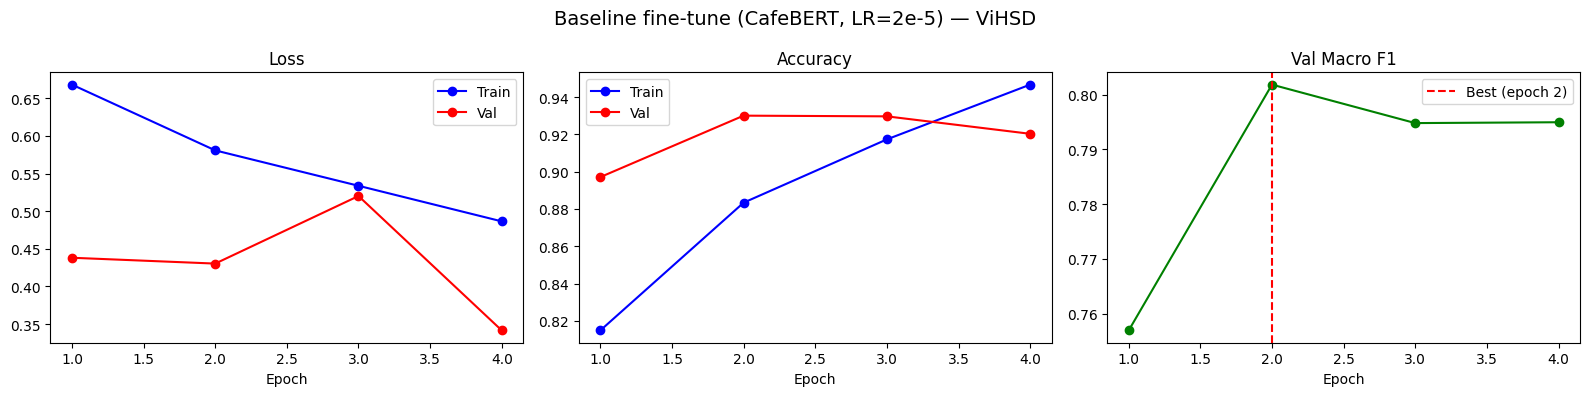

In [14]:
n = len(history['train_loss']); er = range(1, n + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(er, history['train_loss'], 'b-o', label='Train')
axes[0].plot(er, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(er, history['train_acc'], 'b-o', label='Train')
axes[1].plot(er, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
axes[2].plot(er, history['val_f1'], 'g-o')
axes[2].axvline(best_epoch, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
axes[2].set_title('Val Macro F1'); axes[2].legend(); axes[2].set_xlabel('Epoch')
plt.suptitle(PLOT_TITLE, fontsize=14); plt.tight_layout()
plt.savefig(f'training_curves_baseline_{RUN_TAG}.png', dpi=150); plt.show()

In [15]:
ckpt = torch.load(CKPT_NAME, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
threshold = ckpt['threshold']
model.eval()
print(f'Loaded best checkpoint (epoch {best_epoch}, threshold={threshold:.2f})')

all_probs, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            logits = model(ids, mask)
        all_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

y_prob = np.array(all_probs)
y_true = np.array(all_labels)
y_pred = (y_prob >= threshold).astype(int)
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4, zero_division=0))

Loaded best checkpoint (epoch 2, threshold=0.76)
              precision    recall  f1-score   support

    NON-HATE     0.9507    0.9665    0.9585      5992
        HATE     0.6587    0.5640    0.6077       688

    accuracy                         0.9250      6680
   macro avg     0.8047    0.7652    0.7831      6680
weighted avg     0.9207    0.9250    0.9224      6680



Accuracy        : 0.9250
Macro Precision : 0.8047
Macro Recall    : 0.7652
Macro F1        : 0.7831
F1 (HATE)       : 0.6077


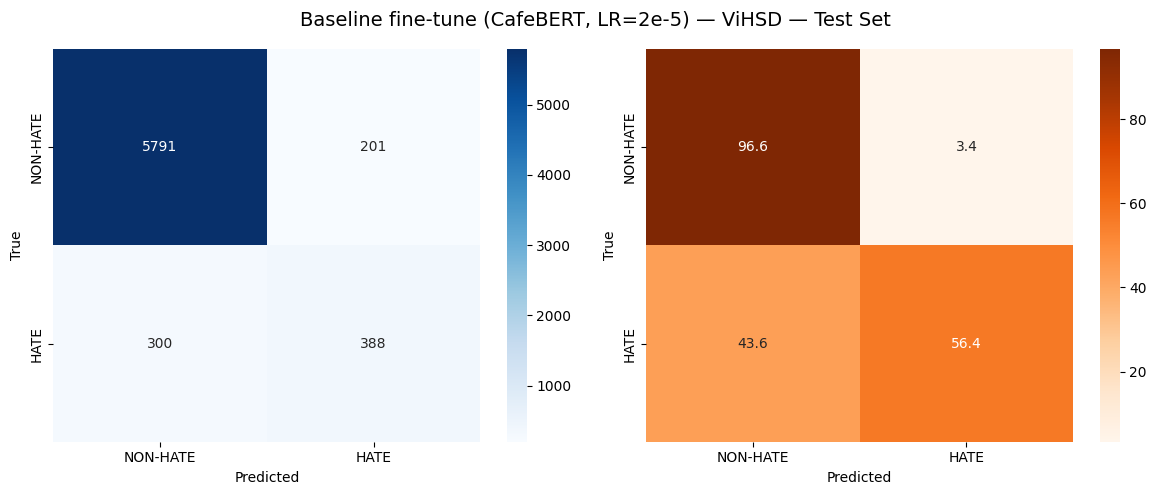

In [16]:
acc      = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro',    zero_division=0)
macro_p  = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_r  = recall_score(y_true, y_pred, average='macro',    zero_division=0)
hate_f1  = f1_score(y_true, y_pred, labels=[1], average='macro', zero_division=0)

print(f"Accuracy        : {acc:.4f}")
print(f"Macro Precision : {macro_p:.4f}")
print(f"Macro Recall    : {macro_r:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"F1 (HATE)       : {hate_f1:.4f}")

# Δ vs YOUR proposed ViAmpleHate test results (fill the constants in the config cell)
if PROPOSED_MACRO_F1 is not None:
    print(f"\nΔ Macro F1 (proposed − this): {PROPOSED_MACRO_F1 - macro_f1:+.4f}")
if PROPOSED_HATE_F1 is not None:
    print(f"Δ HATE F1  (proposed − this): {PROPOSED_HATE_F1 - hate_f1:+.4f}")

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm,     annot=True, fmt='d',   cmap='Blues',   ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
for ax in axes: ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle(PLOT_TITLE + ' — Test Set', fontsize=14); plt.tight_layout()
plt.savefig(f'confusion_matrix_baseline_{RUN_TAG}.png', dpi=150); plt.show()

In [17]:
os.makedirs('outputs', exist_ok=True)
config = {
    'notebook'          : f'vihsd-baseline-{MODEL_TAG}-lr2e5',
    'method'            : 'Plain fine-tune (encoder + linear on CLS)',
    'encoder'           : MODEL_NAME,
    'max_len'           : MAX_LEN,
    'hidden_dim'        : HIDDEN_DIM,
    'batch_size'        : BATCH_SIZE,
    'grad_accum'        : GRAD_ACCUM,
    'dropout'           : DROPOUT,
    'label_smoothing'   : LABEL_SMOOTHING,
    'lr_encoder'        : float(LR),
    'lr_head'           : float(HEAD_LR),
    'num_classes'       : NUM_CLASSES,
    'label_names'       : LABEL_NAMES,
    'best_epoch'        : int(best_epoch),
    'best_val_f1'       : round(float(best_f1), 4),
    'best_threshold'    : round(float(threshold), 2),
    'test_accuracy'     : round(float(acc), 4),
    'test_macro_f1'     : round(float(macro_f1), 4),
    'test_macro_p'      : round(float(macro_p), 4),
    'test_macro_r'      : round(float(macro_r), 4),
    'test_f1_hate'      : round(float(hate_f1), 4),
}
if PROPOSED_MACRO_F1 is not None:
    config['proposed_macro_f1']  = PROPOSED_MACRO_F1
    config['delta_macro_f1']     = round(PROPOSED_MACRO_F1 - float(macro_f1), 4)
if PROPOSED_HATE_F1 is not None:
    config['proposed_hate_f1']   = PROPOSED_HATE_F1
    config['delta_hate_f1']      = round(PROPOSED_HATE_F1 - float(hate_f1), 4)

with open(f'outputs/baseline_{RUN_TAG}_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print(json.dumps(config, indent=2, ensure_ascii=False))

{
  "notebook": "vihsd-baseline-cafebert-lr2e5",
  "method": "Plain fine-tune (encoder + linear on CLS)",
  "encoder": "uitnlp/CafeBERT",
  "max_len": 256,
  "hidden_dim": 1024,
  "batch_size": 8,
  "grad_accum": 4,
  "dropout": 0.1,
  "label_smoothing": 0.05,
  "lr_encoder": 2e-05,
  "lr_head": 5e-05,
  "num_classes": 2,
  "label_names": [
    "NON-HATE",
    "HATE"
  ],
  "best_epoch": 2,
  "best_val_f1": 0.8018,
  "best_threshold": 0.76,
  "test_accuracy": 0.925,
  "test_macro_f1": 0.7831,
  "test_macro_p": 0.8047,
  "test_macro_r": 0.7652,
  "test_f1_hate": 0.6077
}
